In [17]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder, StandardScaler 

import warnings 
warnings.filterwarnings("ignore") 
warnings.filterwarnings("ignore",category = DeprecationWarning)

In [18]:
file_path = '/kaggle/input/british-airways-custome-booking/customer_booking.csv' 
df = pd.read_csv(file_path,encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [19]:
#To compute the total number of missing values in the data frame.
print(df.isnull().sum())


num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64


The .info() method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

num_passengers = number of passengers travelling
sales_channel = sales channel booking was made on
trip_type = trip Type (Round Trip, One Way, Circle Trip)
purchase_lead = number of days between travel date and booking date
length_of_stay = number of days spent at destination
flight_hour = hour of flight departure
flight_day = day of week of flight departure
route = origin -> destination flight route
booking_origin = country from where booking was made
wants_extra_baggage = if the customer wanted extra baggage in the booking
wants_preferred_seat = if the customer wanted a preferred seat in the booking
wants_in_flight_meals = if the customer wanted in-flight meals in the booking
flight_duration = total duration of flight (in hours)
booking_complete = flag indicating if the customer completed the booking
Before we compute any statistics on the data, lets do any necessary data conversion



**Exploratory Data Analysis (EDA) **is an essential step in any data analysis workflow. The goal is to understand the data better by summarizing its main characteristics, often visualizing it to uncover patterns, detect anomalies, test assumptions, and check for relationships between variables.

In [20]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [21]:
#their datatypes, and missing values.
print("Generate the summary of the Data Frame:")
print(df.info())
print("-----------------------------------------------------------------------------------------------------------------------------------------------------")
#df.shape() display Total no of rows and columns data frame
print("Total no of rows and columns Data Frame:",df.shape)
print("-----------------------------------------------------------------------------------------------------------------------------------------------------")
#Return the memory usage of each column in bytes.
print("Memory Usage of each column in bytes:","\n",df.memory_usage(index=True, deep=True))

Generate the summary of the Data Frame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1),

**Data visualization **

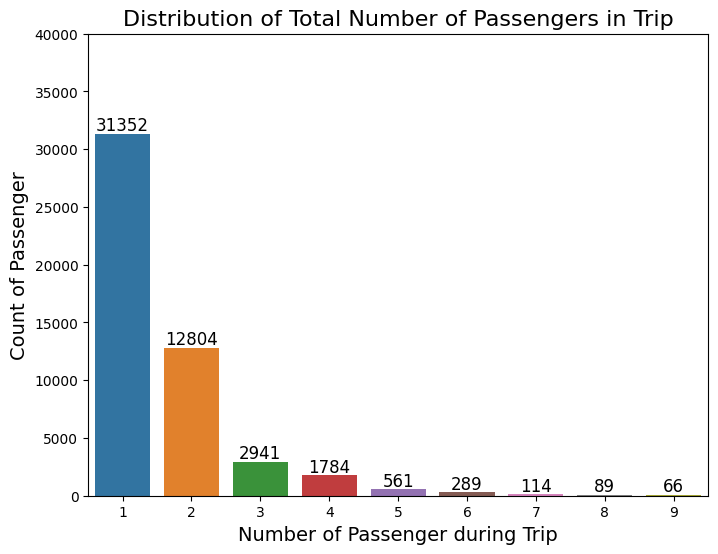

In [22]:
# 1. Bar Plot for Number of Passenger during Trip
# Assuming df is already defined
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='num_passengers', data=df)

# Set the Y-axis limit to 40,000
plt.ylim(0, 40000)

# Adding counts on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 700,f'{int(height)}', ha='center', va='center', fontsize=12, color='black')

# Add title and labels
plt.title('Distribution of Total Number of Passengers in Trip', fontsize=16)
plt.xlabel('Number of Passenger during Trip', fontsize=14) 
plt.ylabel('Count of Passenger', fontsize=14)  
plt.show()

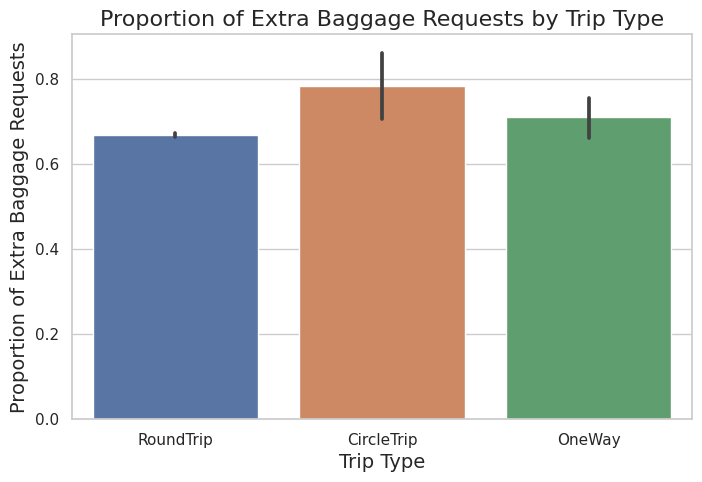

In [23]:
#2. Bar plot for extra baggage requests by trip_type


# Set the plot style
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(x='trip_type', y='wants_extra_baggage', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Proportion of Extra Baggage Requests by Trip Type',fontsize=16)
plt.xlabel('Trip Type',fontsize=14)
plt.ylabel('Proportion of Extra Baggage Requests',fontsize=14)
plt.show()

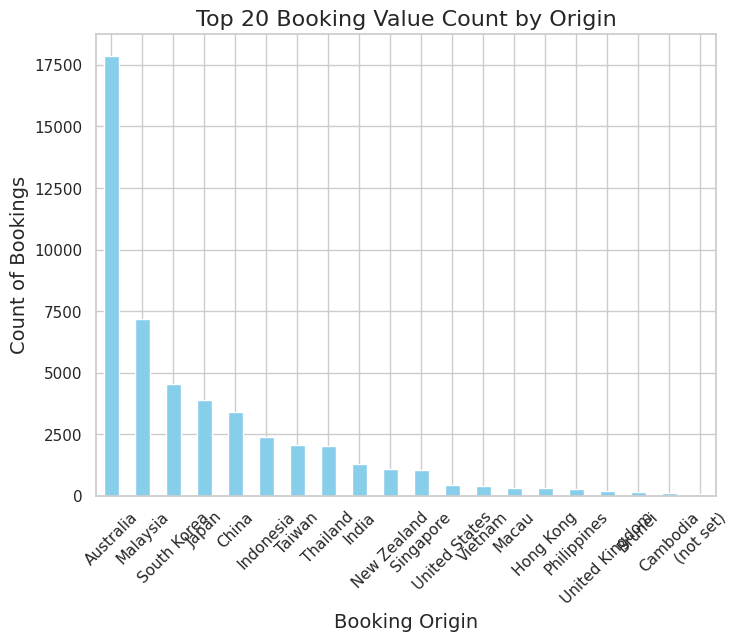

In [24]:
#3. Bar plot the top 20 booking  from origins
# Count the occurrences of each booking origin and get top 20
booking_counts = df['booking_origin'].value_counts().head(20)

# Plotting the booking counts for the top 20
plt.figure(figsize=(8, 6))
booking_counts.plot(kind='bar', color='skyblue')
plt.title('Top 20 Booking Value Count by Origin', fontsize=16)
plt.xlabel('Booking Origin', fontsize=14)
plt.ylabel('Count of Bookings', fontsize=14)
plt.xticks(rotation=45)
plt.show()

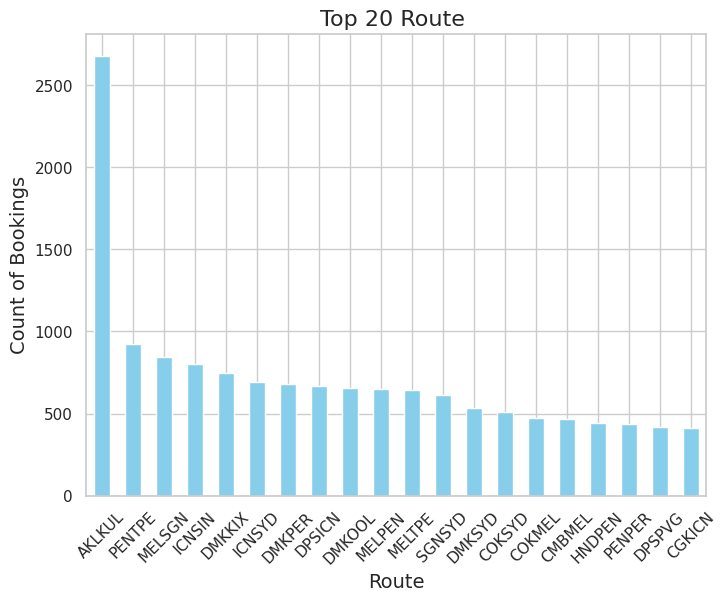

In [25]:
#4. Bar plot the top 20 routes
# Count the occurrences of each booking origin and get top 20
booking_counts = df['route'].value_counts().head(20)

# Plotting the booking counts for the top 20
plt.figure(figsize=(8, 6))
booking_counts.plot(kind='bar', color='skyblue')
plt.title('Top 20 Route ', fontsize=16)
plt.xlabel('Route', fontsize=14)
plt.ylabel('Count of Bookings', fontsize=14)
plt.xticks(rotation=45)
plt.show()

**Data preprocessing** and **Feature engineering** 

Feature engineering is the process of creating new input features or modifying existing features in a dataset to improve the performance of machine learning models


Categorical data needs to be encoded into numerical format for machine learning algorithms.

In [26]:

# 1. Apply Label Encoding to 'sales_channel' 
label_encoder = LabelEncoder()
df['sales_channel'] = label_encoder.fit_transform(df['sales_channel'])

# 2. Apply Label Encoding to 'trip_type'
df['trip_type'] = label_encoder.fit_transform(df['trip_type'])

# 3.mapping for 'flight_day'

mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

# 4. Feature engineering Add a new column for Weekday/Weekend and lable encoding
df['days_of_week'] = df['flight_day'].apply(lambda x: 'Weekend' if x == 6 or x == 7 else 'Weekday')
df['days_of_week'] = label_encoder.fit_transform(df['days_of_week'])

# 5. Frequency Encoding for 'booking_origin'
origin_counts = df['booking_origin'].value_counts()
df['booking_origin'] = df['booking_origin'].map(origin_counts)

# 6. Frequency Encoding for 'route'
route_counts = df['route'].value_counts()
df['route'] = df['route'].map(route_counts)

# 7. Feature engineering To categorize flight hours into the time of day and lable encoding 
# Define a function to categorize flight hours based on time of day
def categorize_flight_hour(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Apply the categorization to the flight hours
categorized_flight_hours = [categorize_flight_hour(hour) for hour in df['flight_hour']]
df['flight_time']=categorized_flight_hours
df['flight_time'] = label_encoder.fit_transform(df['flight_time'])

# 8. Feature engineering to Create a new column 'premium_service' 
df['premium_service'] = df[['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']].any(axis=1).astype(int)

# Display the result
print(df.head())

   num_passengers  sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2              0          2            262              19   
1               1              0          2            112              20   
2               2              0          2            243              22   
3               1              0          2             96              31   
4               2              0          2             68              22   

   flight_hour  flight_day  route  booking_origin  wants_extra_baggage  \
0            7           6     20            1074                    1   
1            3           6     20            1074                    0   
2           17           3     20            1270                    1   
3            4           6     20            1074                    0   
4           15           3     20            1270                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                  

**Inferential Analysis with Machine Learning**

In [27]:
import statsmodels.api as sm
from scipy.stats import spearmanr,chi2_contingency,chi2


Correlation Matrix:
               sales_channel  trip_type
sales_channel       1.000000   0.021237
trip_type           0.021237   1.000000


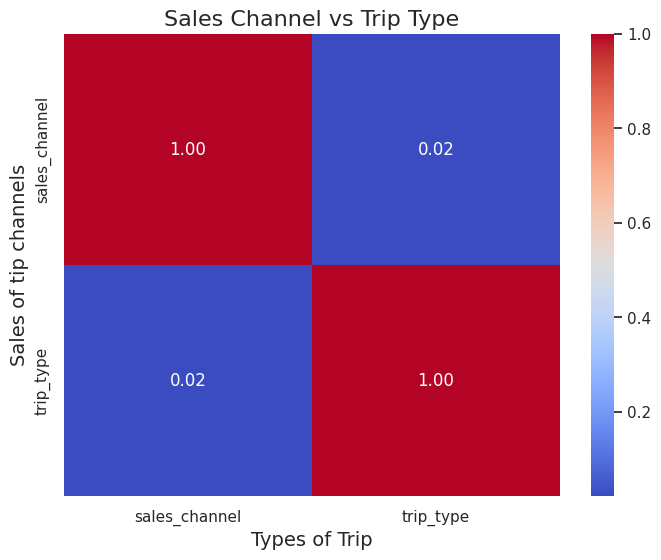

In [28]:
# 1.correlation Analysis for  Sales Channel vs Trip Type Heatmap

# Calculate the correlation matrix for the encoded columns
correlation_matrix = df[['sales_channel', 'trip_type']].corr()

# Print the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Create the heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

plt.title('Sales Channel vs Trip Type', fontsize=16)
plt.xlabel('Types of Trip', fontsize=14) 
plt.ylabel('Sales of tip channels', fontsize=14)

plt.show()

Correlation between sales_channel_encoded and trip_type_encoded:
1.The correlation value is 0.021237, which indicates a very weak positive correlation between the sales_channel (Internet vs. Mobile) and trip_type (RoundTrip vs. CircleTrip) in your data.

2.This is a very low correlation, meaning that the sales channel (whether the trip was booked through the Internet or Mobile) has almost no influence on the type of trip (RoundTrip or CircleTrip).

3.The 0.02 correlation is so close to 0 that it can be interpreted as essentially no correlation. This suggests that the sales_channel doesn't affect the trip_type significantly.

Correlation of sales_channel_encoded with itself:

1.The correlation of 1.0 between sales_channel_encoded and itself is expected because a variable is always perfectly correlated with itself.

Correlation of trip_type_encoded with itself:

1.Similarly, the correlation value of 1.0 between trip_type_encoded and itself is expected.

Spearman's Rank Correlation between Purchase Lead and Flight Day: 0.04


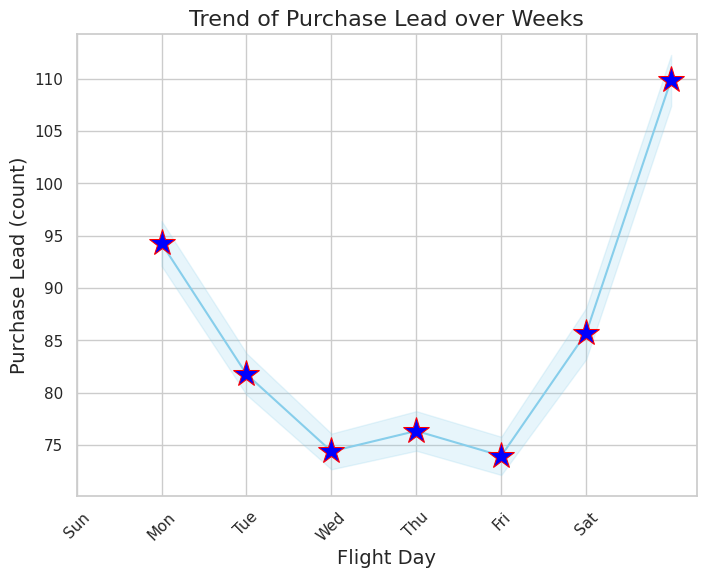

In [29]:
# 2. Calculate Spearman's rank correlation between Purchase Lead and Flight Day Numeric and plot to visualize trends over weeks

correlation, _ = spearmanr(df['purchase_lead'], df['flight_day'])
print(f"Spearman's Rank Correlation between Purchase Lead and Flight Day: {correlation:.2f}")

# Line plot to visualize trends in the data with day names
plt.figure(figsize=(8, 6))
sns.lineplot(x='flight_day', y='purchase_lead', data=df, marker='*',
             markerfacecolor='blue',
             markersize=20,  # Adjust scaling for better visibility
             markeredgecolor='red', color='skyblue')

# Title and labels
plt.title('Trend of Purchase Lead over Weeks',fontsize=16)
plt.xlabel('Flight Day',fontsize=14)
plt.ylabel('Purchase Lead (count)',fontsize=14)

# Customizing the x-axis to display days of the week
days_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

# Adjusting the x-ticks based on the day labels
plt.xticks(ticks=range(0, 7), labels=days_order, rotation=45)

# Adding gridlines for better readability
plt.grid(True)

# Show the plot
plt.show()

The Pearson correlation of 0.04 between purchase_lead and flight_day indicates a very weak positive correlation. A correlation of 0.04 is very close to 0, meaning there is almost no linear relationship between the two variables.

Null Hypothesis (H₀): There is no relationship between trip_type and wants_in_flight_meals (i.e., the variables are independent).
Alternative Hypothesis (H₁): There is a relationship between trip_type and wants_in_flight_meals (i.e., the variables are dependent).

Chi-square Test Results:
Chi-square Statistic: 10.89162405511368
P-value: 0.00431433522574318
Degrees of Freedom: 2

Expected Frequencies Table:
[[   66.45176    49.54824]
 [  221.69682   165.30318]
 [28354.85142 21142.14858]]

Reject the null hypothesis: There is a significant relationship between trip_type and wants_in_flight_meals.


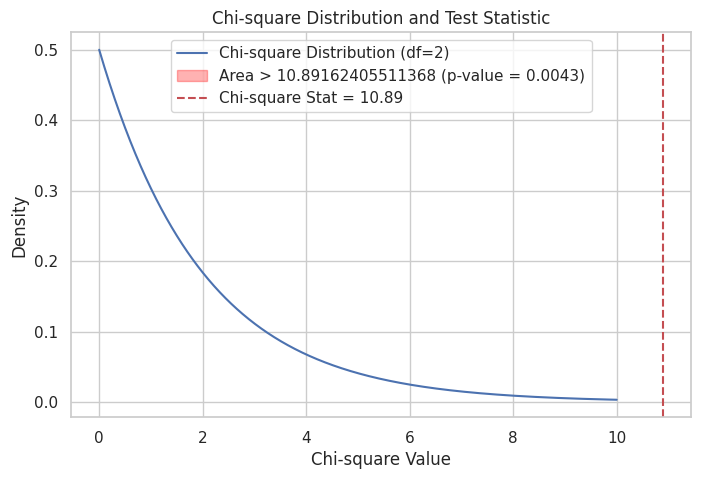

In [30]:
#3.Chi-square Test for Independence  between trip_type (RoundTrip or other types) and wants_in_flight_meals.
# Set up the hypotheses
null_hypothesis = "Null Hypothesis (H₀): There is no relationship between trip_type and wants_in_flight_meals (i.e., the variables are independent)."
alternative_hypothesis = "Alternative Hypothesis (H₁): There is a relationship between trip_type and wants_in_flight_meals (i.e., the variables are dependent)."

# Print the hypotheses
print(null_hypothesis)
print(alternative_hypothesis)

# Create a contingency table for 'trip_type' and 'wants_in_flight_meals'
contingency_table = pd.crosstab(df['trip_type'], df['wants_in_flight_meals'])

# Perform Chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Output the results of the Chi-square test
print("\nChi-square Test Results:")
print(f"Chi-square Statistic: {chi2_stat}")
print(f"P-value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(expected)

# Interpretation based on p-value
alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis: There is a significant relationship between trip_type and wants_in_flight_meals.")
else:
    print("\nFail to reject the null hypothesis: There is no significant relationship between trip_type and wants_in_flight_meals.")

# Plotting Chi-square distribution with p-value shading
x = np.linspace(0, 10, 1000)
chi_square_curve = chi2.pdf(x, df=dof)

plt.figure(figsize=(8, 5))
plt.plot(x, chi_square_curve, label=f'Chi-square Distribution (df={dof})')
plt.fill_between(x, chi_square_curve, where=(x > chi2_stat), color='red', alpha=0.3, label=f'Area > {chi2_stat} (p-value = {p_value:.4f})')
plt.axvline(x=chi2_stat, color='r', linestyle='--', label=f'Chi-square Stat = {chi2_stat:.2f}')
plt.title(f'Chi-square Distribution and Test Statistic')
plt.xlabel('Chi-square Value')
plt.ylabel('Density')
plt.legend()
plt.show()

Since the p-value (0.0043) is less than the significance level (α = 0.05), we reject the null hypothesis. This means that there is a statistically significant relationship between trip_type and wants_in_flight_meals. The two variables are dependent, and the type of trip may influence whether passengers request in-flight meals.

**Predictive machine learning** analysis refers to the use of machine learning algorithms and techniques to forecast future events or outcomes based on historical data. Predective Machine learning analysis

Supervised learning classification is a type of machine learning where the model is trained on a labeled dataset. In this type of learning, the algorithm is provided with input-output pairs, where the input is typically a set of features, and the output is a class label. The goal is for the model to learn the relationship between the input features and the corresponding class labels, so that it can predict the class label for new, unseen data.  





Common algorithms used for supervised classification include:
Logistic Regression
Decision Trees
Random Forests
Support Vector Machines (SVM)
K-Nearest Neighbors (KNN)
Naive Bayes
Neural Networks




The model’s performance is measured using metrics such as:
Accuracy: The proportion of correct predictions.
Precision: The proportion of true positives among all predicted positives.
Recall (Sensitivity): The proportion of true positives among all actual positives.
F1 Score: The harmonic mean of precision and recall.
Confusion Matrix: A table used to evaluate the performance of a classification algorithm.



In [31]:
from sklearn.model_selection import GridSearchCV, train_test_split,cross_val_score


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import  accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

In [41]:
# 1. Predicting the probability of premium_service based on factors of data frame 

# Add a constant to the independent variable (for the intercept)
X = sm.add_constant(df[['num_passengers','purchase_lead','flight_time','trip_type','length_of_stay','days_of_week','route','flight_duration']])
y = df['premium_service']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Best estimator of Logistic Regression from Grid Search: LogisticRegression(penalty='l1', solver='liblinear')

Training Accuracy: 0.789825
Testing Accuracy: 0.7952


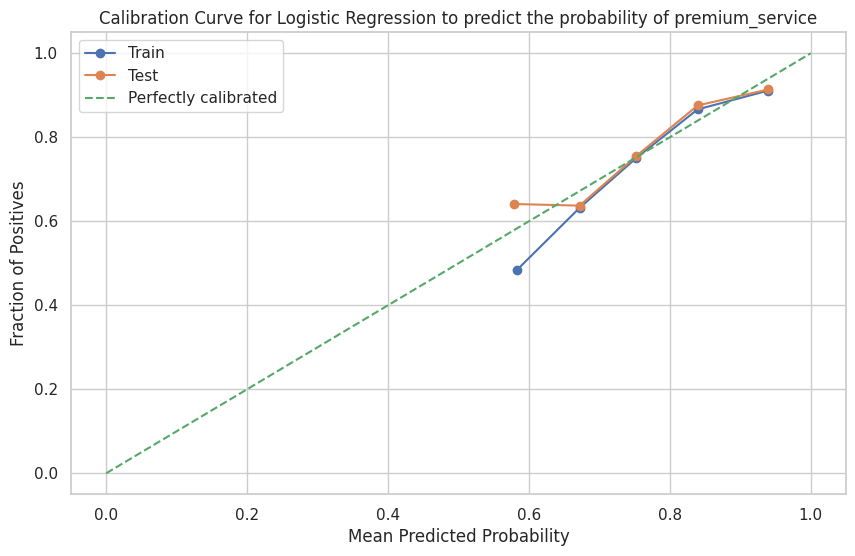

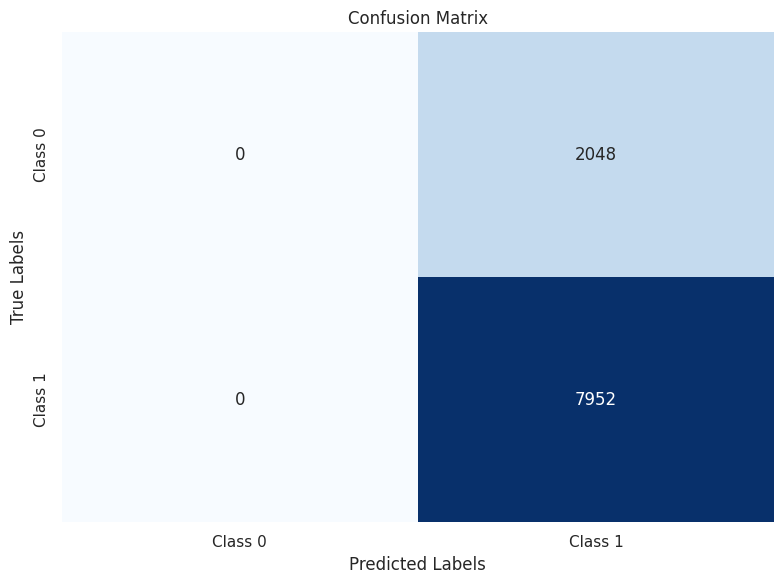

In [42]:
#********************************************.Losgistic Regresion Model  with tunning **************************************************************************************************************
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression()

# Define the parameter grid for hyperparameter tuning (you can tune other hyperparameters as well)
param_grid = {"penalty": ['l1', 'l2'], "solver": ['liblinear', 'saga']}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(log_reg_model, param_grid, cv=5, scoring="accuracy")
grid_search.fit(x_train, y_train)

# Get the best estimator after the grid search
best_estimator_lr = grid_search.best_estimator_

# Predictions on both the training and testing datasets
train_predictions = best_estimator_lr.predict(x_train)
test_predictions = best_estimator_lr.predict(x_test)

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print the results
print("Best estimator of Logistic Regression from Grid Search:", best_estimator_lr)
print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Now, generate the calibration curve
prob_train = best_estimator_lr.predict_proba(x_train)[:, 1]  # predicted probabilities for class 1
prob_test = best_estimator_lr.predict_proba(x_test)[:, 1]    # predicted probabilities for class 1

# Compute the calibration curve for both train and test data
fraction_of_positives_train, mean_predicted_value_train = calibration_curve(y_train, prob_train, n_bins=10)
fraction_of_positives_test, mean_predicted_value_test = calibration_curve(y_test, prob_test, n_bins=10)

# Plot the calibration curve
plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value_train, fraction_of_positives_train, label="Train", marker='o')
plt.plot(mean_predicted_value_test, fraction_of_positives_test, label="Test", marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', label="Perfectly calibrated")
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve for Logistic Regression to predict the probability of premium_service')
plt.legend()
plt.show()

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_predictions)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

# Set plot labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Display the plot
plt.tight_layout()
plt.show()

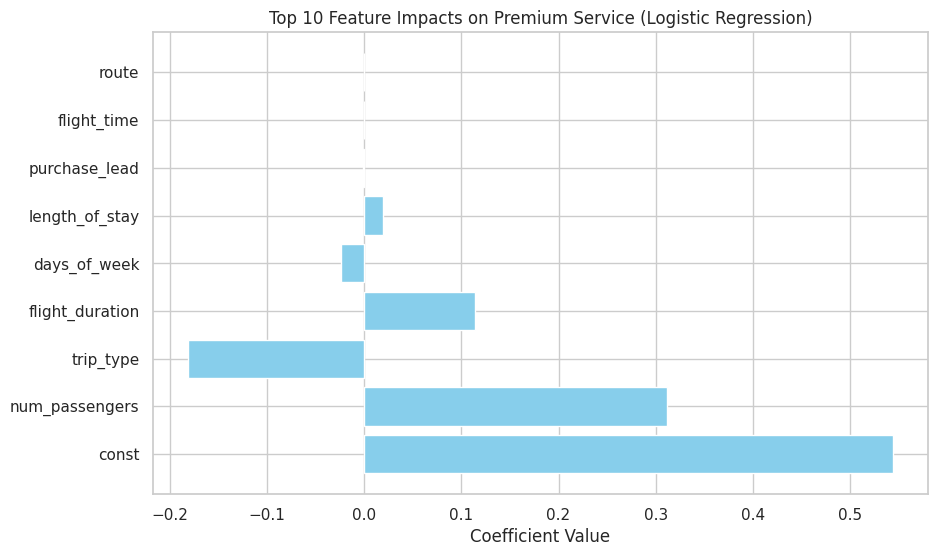

Top 10 Features Based on Impact (Coefficient Values):
           Feature  Coefficient
0            const     0.543586
1   num_passengers     0.311210
4        trip_type    -0.181114
8  flight_duration     0.113712
6     days_of_week    -0.024240
5   length_of_stay     0.019878
2    purchase_lead    -0.001375
3      flight_time    -0.000192
7            route    -0.000105


In [35]:
# Get the coefficients of the Logistic Regression model
coefficients = best_estimator_lr.coef_[0]  # Get the coefficients (first row in case of multiple classes)

# Get the feature names (X columns)
feature_names = x_train.columns

# Create a DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort the features by the absolute value of the coefficients to find the most impactful ones
coef_df['Abs Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs Coefficient', ascending=False)

# Plot the top features based on absolute coefficient values
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'].head(10), coef_df['Coefficient'].head(10), color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Impacts on Premium Service (Logistic Regression)')
plt.grid(True)
plt.show()

# Print the top 10 features with the largest coefficient impact
print("Top 10 Features Based on Impact (Coefficient Values):")
print(coef_df[['Feature', 'Coefficient']].head(10))

Best estimator of Random Forest from Grid Search: RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

Training Accuracy: 0.796775
Testing Accuracy: 0.7955


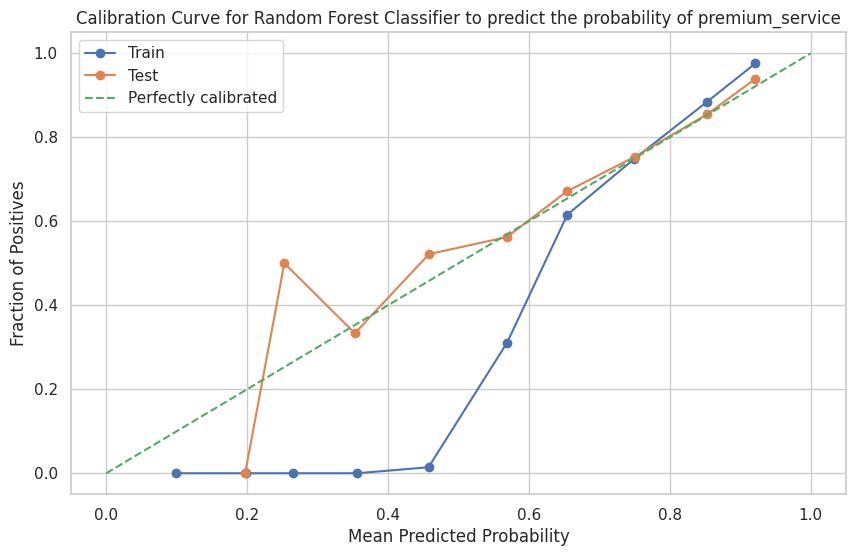

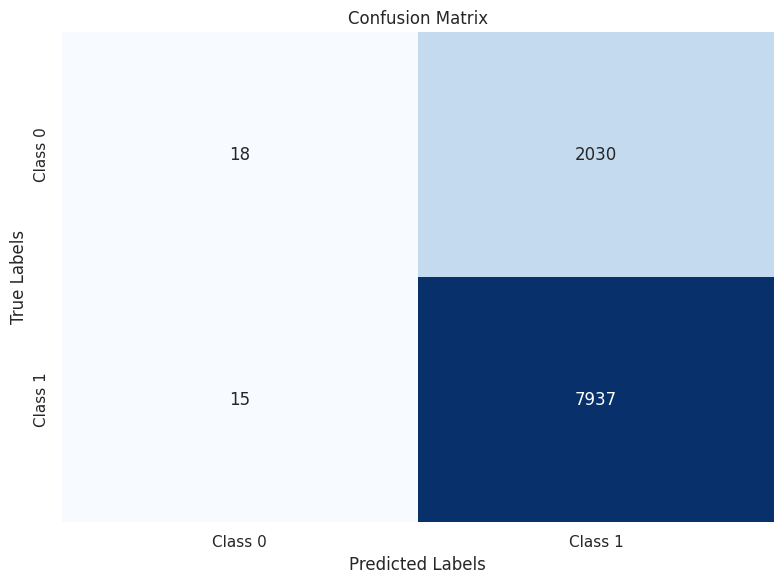

In [43]:
#********************************************Random Forest Classifier with Tuning****************************************************************

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring="accuracy")
grid_search.fit(x_train, y_train)

# Get the best estimator after the grid search
best_estimator_rf = grid_search.best_estimator_

# Predictions on both the training and testing datasets
train_predictions = best_estimator_rf.predict(x_train)
test_predictions = best_estimator_rf.predict(x_test)

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print the results
print("Best estimator of Random Forest from Grid Search:", best_estimator_rf)
print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Now, generate the calibration curve
prob_train = best_estimator_rf.predict_proba(x_train)[:, 1]  # predicted probabilities for class 1
prob_test = best_estimator_rf.predict_proba(x_test)[:, 1]    # predicted probabilities for class 1

# Compute the calibration curve for both train and test data
fraction_of_positives_train, mean_predicted_value_train = calibration_curve(y_train, prob_train, n_bins=10)
fraction_of_positives_test, mean_predicted_value_test = calibration_curve(y_test, prob_test, n_bins=10)

# Plot the calibration curve
plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value_train, fraction_of_positives_train, label="Train", marker='o')
plt.plot(mean_predicted_value_test, fraction_of_positives_test, label="Test", marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', label="Perfectly calibrated")
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve for Random Forest Classifier to predict the probability of premium_service')
plt.legend()
plt.show()

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_predictions)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

# Set plot labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Display the plot
plt.tight_layout()
plt.show()

Top Features by Importance:
           Feature  Importance
5   length_of_stay    0.351023
2    purchase_lead    0.207840
7            route    0.154285
8  flight_duration    0.117908
1   num_passengers    0.101405


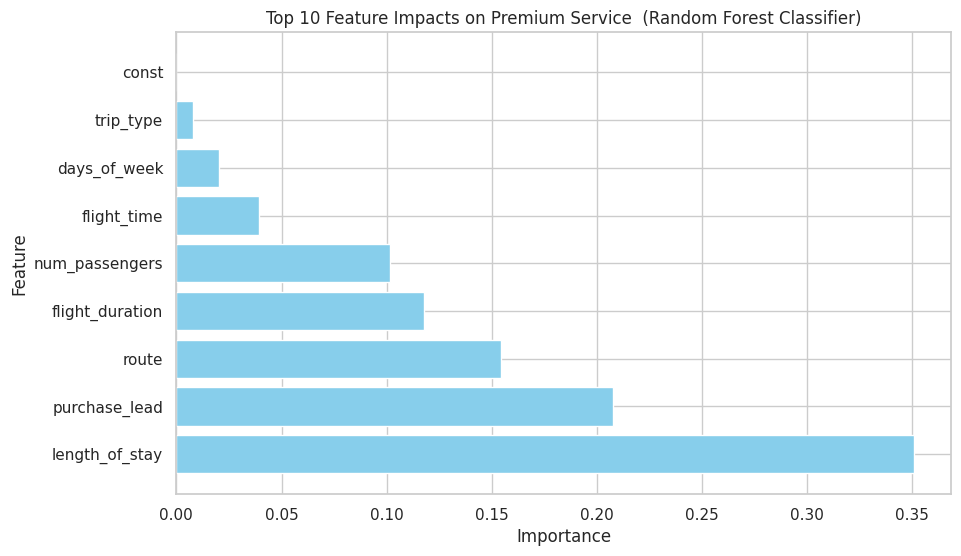

In [38]:
# Get feature importances from the trained model
feature_importances = best_estimator_rf.feature_importances_

# Create a DataFrame to hold features and their importance values
importances_df = pd.DataFrame({
    'Feature': x_train.columns,  # Use x_train.columns instead of X.columns
    'Importance': feature_importances
})

# Sort the DataFrame by the importance value in descending order
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Display the top features
print("Top Features by Importance:")
print(importances_df.head())

# Visualize the feature importances using a bar chart
plt.figure(figsize=(10, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Impacts on Premium Service  (Random Forest Classifier)')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#2. predict the purchase lead time (purchase_lead) based on the features
# Define features (X) and target variable (y)
X = df[['num_passengers','sales_channel','trip_type','length_of_stay','flight_time','days_of_week','flight_duration','premium_service']]
y = df['purchase_lead']

# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Linear Regression model Output:
Training MSE: 7617.719892497847
Testing MSE: 7757.723095417492
Training R²: 0.06579263528009438
Testing R²: 0.06412580288505365


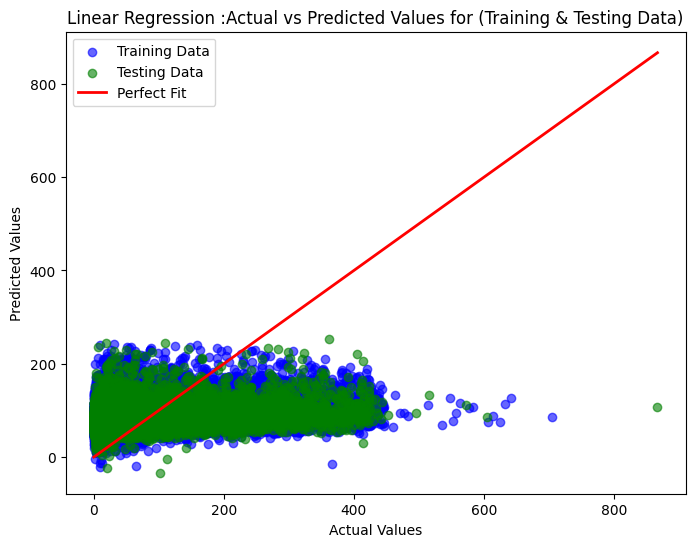

In [16]:

#*******************************************Linear Regression****************************************************************
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predictions on both the training and testing datasets
train_predictions = lr_model.predict(X_train)
test_predictions = lr_model.predict(X_test)

# Calculate performance metrics
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

# Print the results
print("Linear Regression model Output:")

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

# Prediction vs Actual (Training and Testing)
# Scatter plot for both training and testing data on the same plot
plt.figure(figsize=(8, 6))

# Plot for training data
plt.scatter(y_train, train_predictions, color='blue', alpha=0.6, label='Training Data')

# Plot for testing data
plt.scatter(y_test, test_predictions, color='green', alpha=0.6, label='Testing Data')

# Line of perfect fit (45-degree line)
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         color='red', lw=2, label='Perfect Fit')

# Adding titles and labelynomias
plt.title('Linear Regression :Actual vs Predicted Values for (Training & Testing Data)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()


Polynomial Linear Regression model Output:
Training MSE: 7474.853477426937
Testing MSE: 7618.334188721395
Training R²: 0.08331321348641785
Testing R²: 0.0809413658455308


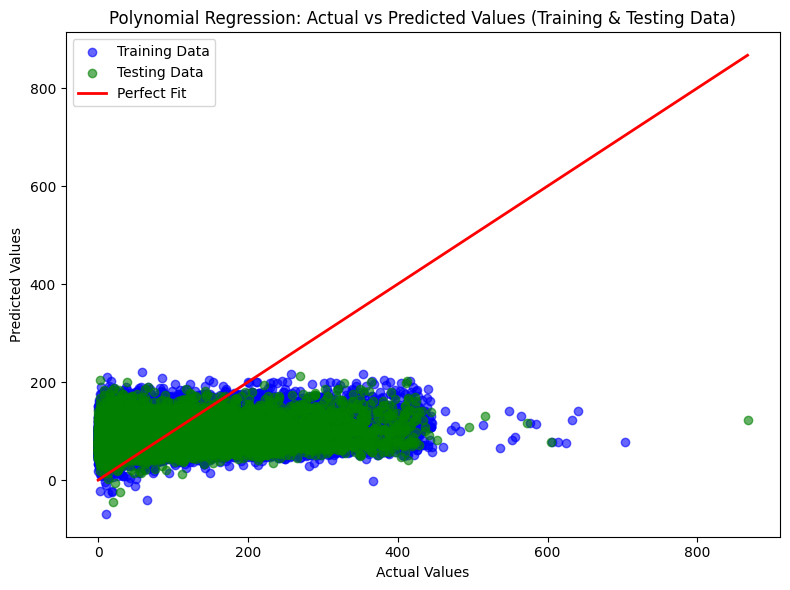

In [15]:

#******************************************Polynomial Features***********************************************************

# Create Polynomial Features (for example, degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the model using polynomial features
poly_lr_model = LinearRegression()
poly_lr_model.fit(X_train_poly, y_train)

# Predictions on both the training and testing datasets
train_predictions_poly = poly_lr_model.predict(X_train_poly)
test_predictions_poly = poly_lr_model.predict(X_test_poly)

# Calculate performance metrics
train_mse_poly = mean_squared_error(y_train, train_predictions_poly)
test_mse_poly = mean_squared_error(y_test, test_predictions_poly)

train_r2_poly = r2_score(y_train, train_predictions_poly)
test_r2_poly = r2_score(y_test, test_predictions_poly)

# Print the results for polynomial features
print("Polynomial Linear Regression model Output:")
print("Training MSE:", train_mse_poly)
print("Testing MSE:", test_mse_poly)
print("Training R²:", train_r2_poly)
print("Testing R²:", test_r2_poly)

#  Plot Prediction vs Actual values for Training and Testing data
plt.figure(figsize=(8, 6))

# Plot for training data
plt.scatter(y_train, train_predictions_poly, color='blue', alpha=0.6, label='Training Data')

# Plot for testing data
plt.scatter(y_test, test_predictions_poly, color='green', alpha=0.6, label='Testing Data')

# Line of perfect fit (45-degree line)
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         color='red', lw=2, label='Perfect Fit')

# Adding titles and labels
plt.title('Polynomial Regression: Actual vs Predicted Values (Training & Testing Data)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()

plt.tight_layout()
plt.show()

Best Hyperparameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Tuned Random Forest Regressor model Output:
Training MSE: 6960.200181758824
Testing MSE: 7417.55492113612
Training R²: 0.14642828018295273
Testing R²: 0.10516292332283894


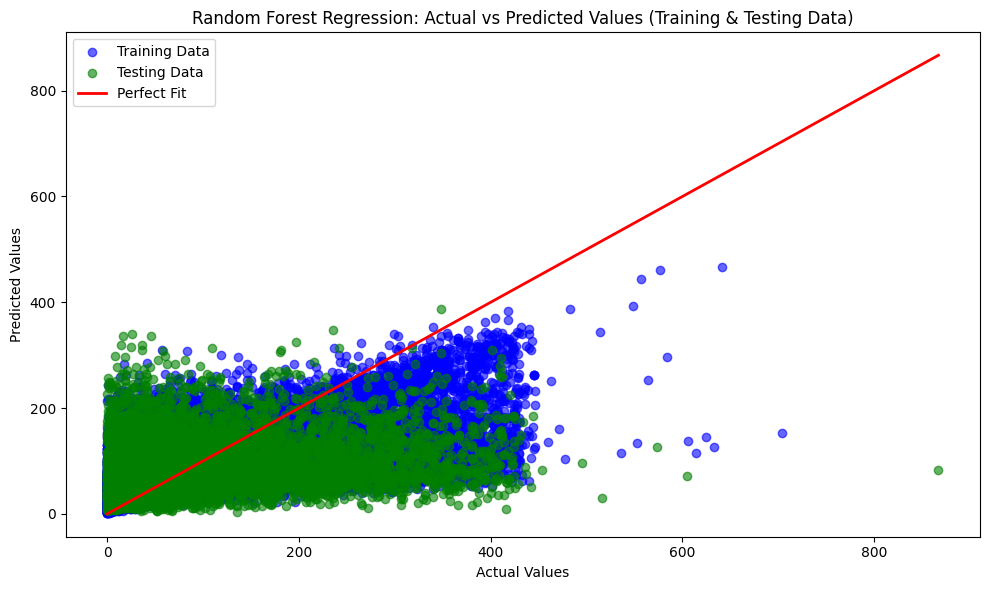

In [14]:

#**************************************Random Forest Regressor Hyperparameters tuning**********************************************************


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Perform Grid Search with Cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best parameters from GridSearch
print("Best Hyperparameters:", grid_search.best_params_)

# Get the best model from the grid search
best_rf_model = grid_search.best_estimator_

# Re-evaluate the best model on training and testing data
train_predictions_best = best_rf_model.predict(X_train)
test_predictions_best = best_rf_model.predict(X_test)

# Calculate performance metrics
train_mse_best = mean_squared_error(y_train, train_predictions_best)
test_mse_best = mean_squared_error(y_test, test_predictions_best)

train_r2_best = r2_score(y_train, train_predictions_best)
test_r2_best = r2_score(y_test, test_predictions_best)

# Print the results
print("Tuned Random Forest Regressor model Output:")
print("Training MSE:", train_mse_best)
print("Testing MSE:", test_mse_best)
print("Training R²:", train_r2_best)
print("Testing R²:", test_r2_best)
# Step 5: Plot Prediction vs Actual values for Training and Testing data
plt.figure(figsize=(10, 6))

# Plot for training data
plt.scatter(y_train, train_predictions_rf, color='blue', alpha=0.6, label='Training Data')

# Plot for testing data
plt.scatter(y_test, test_predictions_rf, color='green', alpha=0.6, label='Testing Data')

# Line of perfect fit (45-degree line)
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         color='red', lw=2, label='Perfect Fit')

# Adding titles and labels
plt.title('Random Forest Regression: Actual vs Predicted Values (Training & Testing Data)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()

plt.tight_layout()
plt.show()

**Unsupervised learning**

It is a type of machine learning where the model is trained on data without explicit labels or supervision.

**Clustering: Grouping data points that are similar to each other into clusters. Common algorithms include:**

K-means :K-means is a popular unsupervised learning algorithm used for clustering. The goal of K-means is to partition a dataset into 𝐾
K distinct clusters, where each data point belongs to the cluster with the nearest mean (centroid). It works by iteratively improving the positions of the centroids and assigning points to the nearest centroid until convergence.


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

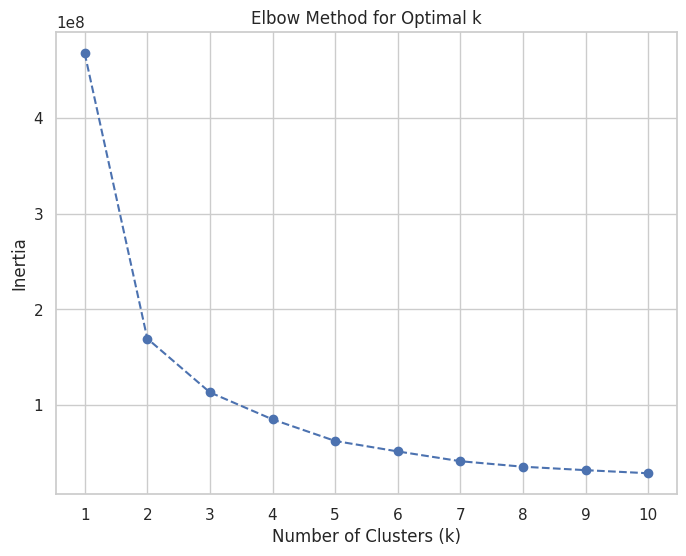

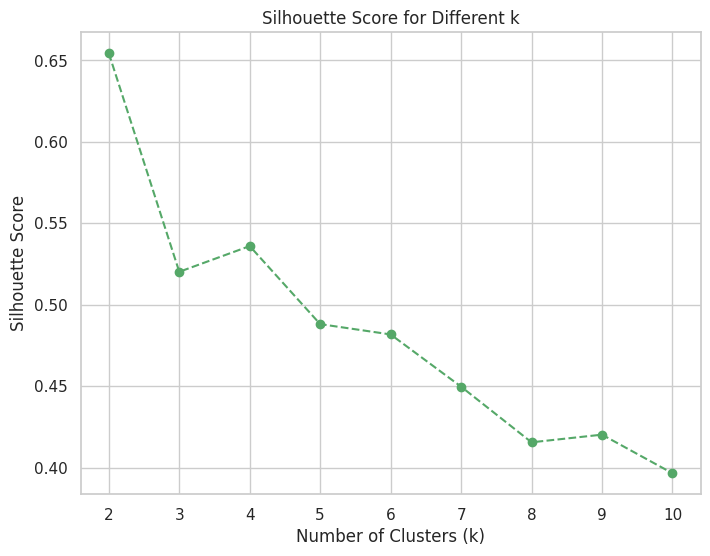

In [45]:
#1.Customer Segmentation (Clustering) (k-means)

# Scaling features for clustering
scaled_features = df[['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 
                      'flight_duration', 'booking_complete', 'premium_service']]



#  Elbow Method (calculate inertia for different number of clusters)
inertia_values = []
sil_scores = []

# Try different values for k (from 1 to 10 clusters)
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)
    
    # Calculate silhouette score for k > 1
    if k > 1:
        sil_score = silhouette_score(scaled_features, kmeans.labels_)
        sil_scores.append(sil_score)

# Plot Elbow Method (Inertia vs. Number of Clusters)
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_values, marker='o', color='b', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

#  Plot Silhouette Scores (for k > 1)
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores, marker='o', color='g', linestyle='--')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


** Elbow Method and Silhouette Score suggest the optimal number of clusters (k) is 2. **

The ideal number of clusters based on both Elbow Method and Silhouette Score is: 2


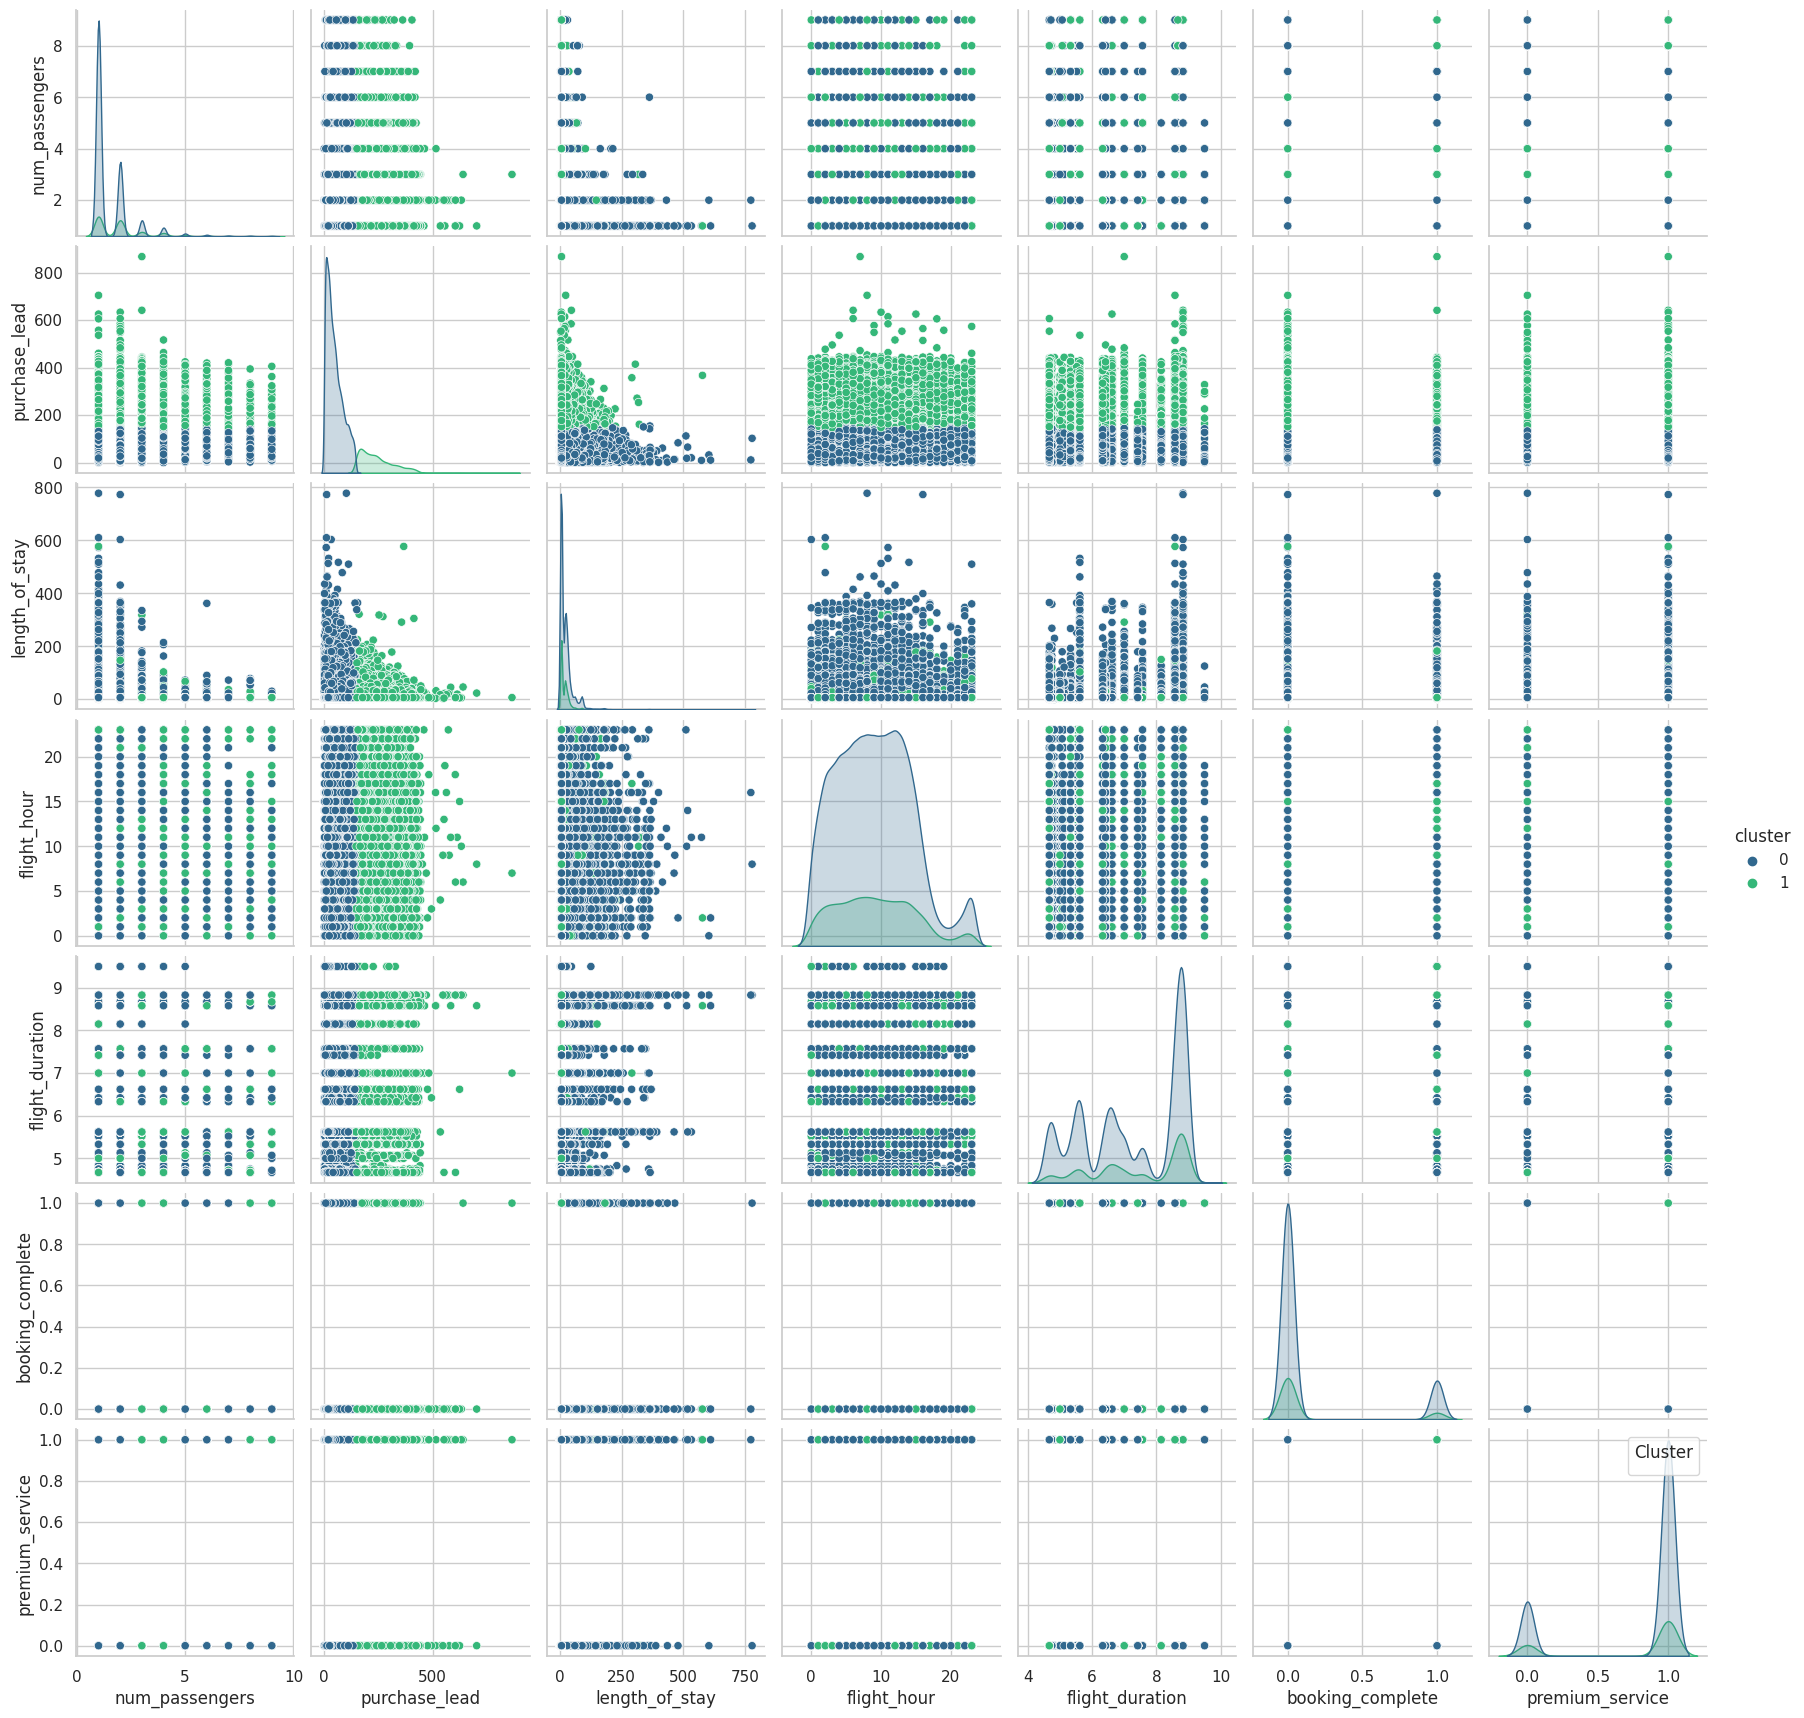


Cluster Summary:
         num_passengers  sales_channel  trip_type  purchase_lead  \
cluster                                                            
0              1.502765       0.113880   1.988096      47.094809   
1              1.959905       0.106025   1.985636     242.639248   

         length_of_stay  flight_hour  flight_day       route  booking_origin  \
cluster                                                                        
0             24.136696     9.012598    3.792253  374.515487     8846.978399   
1             18.493748     9.290276    3.906789  531.711067     8279.221453   

         wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals  \
cluster                                                                     
0                   0.675570              0.297051               0.431813   
1                   0.640488              0.296580               0.407668   

         flight_duration  booking_complete  days_of_week  flight_time  \
cluste

In [48]:
elbow_k = 2  # Based on the elbow plot
silhouette_k = 2  # Based on the highest silhouette score
ideal_k = min(elbow_k, silhouette_k)

print(f"The ideal number of clusters based on both Elbow Method and Silhouette Score is: {ideal_k}")

# Step 7: Apply K-Means clustering with the ideal number of clusters (k = 2)
kmeans = KMeans(n_clusters=ideal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

# Step 8: Visualize the clusters using pairplot
sns.pairplot(df, hue='cluster', palette='viridis', vars=scaled_features)
plt.legend(title='Cluster', loc='best')  # Display legend for clusters
plt.show()

# Step 10: Cluster summary (mean values per cluster)
cluster_summary = df.groupby('cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

# Silhouette Score: Measures how similar each point is to its own cluster vs. other clusters (higher values indicate better clustering)
silhouette_avg = silhouette_score(scaled_features, df['cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Cluster Centers (Centroids):
   num_passengers  purchase_lead  length_of_stay  flight_hour  \
0        1.502740      47.099690       24.137582     9.012498   
1        1.960103     242.659328       18.488889     9.290749   

   flight_duration  booking_complete  premium_service  
0         7.233573          0.152412         0.798264  
1         7.460898          0.137674         0.760207  

Variance of Features Within Each Cluster:
         num_passengers  purchase_lead  length_of_stay  flight_hour  \
cluster                                                               
0              0.895453    1368.849178     1297.122229    28.535182   
1              1.477723    5731.592767      502.944695    32.411907   

         flight_duration  booking_complete  premium_service  
cluster                                                      
0               2.294531          0.129191         0.161048  
1               1.974420          0.118712         0.182286  

Feature Contributions Based on

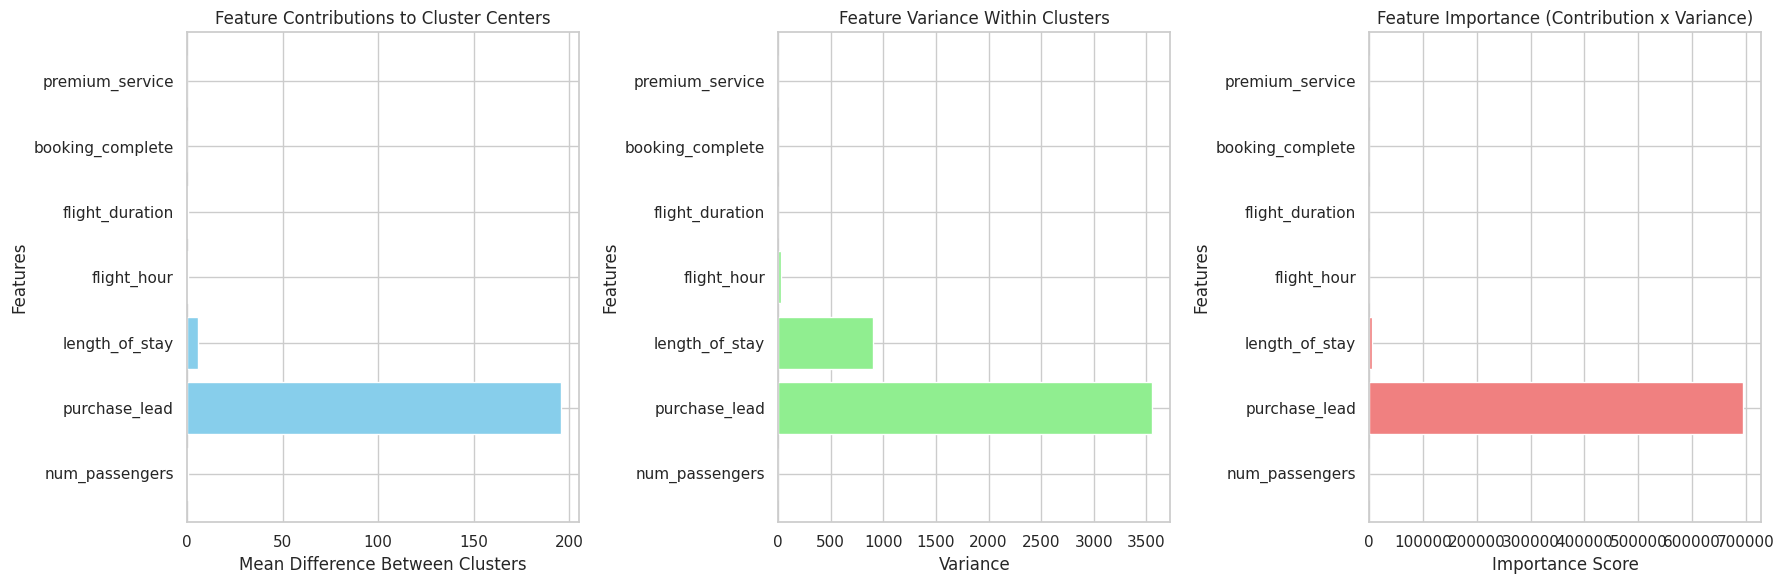

In [49]:
#Extract Feature Importance: each feature to the clustering by looking at cluster centers 

# Extract Cluster Centers (Centroids)
# Pass the column names directly from the DataFrame that contains the features used for clustering (scaled_features)
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df[['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration', 'booking_complete', 'premium_service']].columns)
print("Cluster Centers (Centroids):")
print(cluster_centers)

# Calculate the Variance of Each Feature Within the Clusters
# Add the cluster labels back to the original dataframe
df['cluster'] = kmeans.labels_

# Compute the variance of each feature within each cluster
feature_variance = df.groupby('cluster')[['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration', 'booking_complete', 'premium_service']].var()
print("\nVariance of Features Within Each Cluster:")
print(feature_variance)

# Feature Contribution Based on Cluster Centers
# For simplicity, let's compute the difference between the cluster centers for each feature
# Calculate the difference between cluster centers for each feature
feature_contributions = cluster_centers.diff(axis=0).iloc[1:].abs().mean(axis=0)
print("\nFeature Contributions Based on Cluster Centers:")
print(feature_contributions)

# Combine the insights: Feature Contribution and Variance
# Features with higher variance and greater difference between cluster centers are likely more important
# Combine these two metrics to get a rough sense of importance
feature_importance = feature_contributions * feature_variance.mean(axis=0)
print("\nFeature Importance (Contribution x Variance):")
print(feature_importance)


# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for Feature Contributions
axes[0].barh(feature_contributions.index, feature_contributions.values, color='skyblue')
axes[0].set_title('Feature Contributions to Cluster Centers')
axes[0].set_xlabel('Mean Difference Between Clusters')
axes[0].set_ylabel('Features')

# Plot for Feature Variance
axes[1].barh(feature_variance.mean(axis=0).index, feature_variance.mean(axis=0).values, color='lightgreen')
axes[1].set_title('Feature Variance Within Clusters')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Features')

# Plot for Feature Importance
axes[2].barh(feature_importance.index, feature_importance.values, color='lightcoral')
axes[2].set_title('Feature Importance (Contribution x Variance)')
axes[2].set_xlabel('Importance Score')
axes[2].set_ylabel('Features')

plt.tight_layout()
plt.show()